# Gradient Descent in Practice: Feature Scaling, Convergence & Polynomial Regression

## 1. Executive Summary

This lecture focuses on practical techniques to make gradient descent work efficiently and effectively in real-world machine learning applications. The core theme revolves around three interconnected concepts: feature scaling, convergence monitoring, and learning rate selection. These techniques address common challenges when applying gradient descent to datasets with features of varying scales and complex relationships.

The learning objectives include understanding why feature scaling accelerates gradient descent, implementing different normalization techniques (mean normalization and z-score normalization), developing methods to monitor convergence through learning curves, and strategically selecting appropriate learning rates. Additionally, the lecture introduces feature engineering and polynomial regression as powerful extensions to linear regression, enabling the fitting of non-linear relationships while maintaining the interpretability of linear models.

## 2. Key Concepts & Glossary

| Term | Definition |
|------|------------|
| **Feature Scaling** | Transforming features to have comparable ranges of values to prevent certain features from dominating the gradient descent process |
| **Mean Normalization** | Rescaling features by subtracting the mean and dividing by the range (max-min), centering values around zero |
| **Z-score Normalization** | Rescaling features using mean and standard deviation, resulting in features with zero mean and unit variance |
| **Learning Curve** | Plot showing the cost function value over gradient descent iterations to monitor convergence |
| **Convergence** | The point at which additional iterations produce minimal decrease in the cost function |
| **Learning Rate ($\alpha$)** | Step size parameter controlling how much parameters are adjusted during each gradient descent iteration |
| **Feature Engineering** | Creating new features by transforming or combining original features based on domain knowledge |
| **Polynomial Regression** | Extending linear regression by including polynomial terms (e.g., $x^2$, $x^3$) to fit curved relationships |
| **Automatic Convergence Test** | Using a threshold $\epsilon$ to declare convergence when cost decrease falls below this value |
| **Global Minimum** | The lowest possible value of the cost function that gradient descent aims to find |

## 3. Important Data Points

### Key Formulas

| Formula | Description | Components |
|---------|-------------|------------|
| $f_{\vec{w},b}(\vec{x}) = w_1x_1 + w_2x_2 + b$ | Multiple linear regression model | $w_i$: parameters, $x_i$: features, $b$: bias |
| $x_{norm} = \frac{x - \mu}{max - min}$ | Mean normalization | $\mu$: feature mean, $max, min$: feature range |
| $x_{norm} = \frac{x - \mu}{\sigma}$ | Z-score normalization | $\sigma$: standard deviation |
| $J(\vec{w},b)$ | Cost function to minimize | Measures prediction error |
| $\epsilon = 10^{-3}$ | Typical convergence threshold | Small value for automatic convergence test |

## 4. Core Concepts

### 4.1 Feature Scaling: Why Size Matters

When features have vastly different ranges, gradient descent becomes inefficient. Consider predicting house prices with two features: size ($x_1$: 300-2000 sq ft) and number of bedrooms ($x_2$: 0-5). The feature with larger range (size) will have a disproportionately large influence on the cost function because small changes to $w_1$ cause large changes in predictions. This creates elongated contour plots where gradient descent oscillates, taking many iterations to converge.

The intuition: features with larger ranges require smaller parameter values, while features with smaller ranges need larger parameters. Scaling brings all features to comparable ranges, creating more circular contours and enabling gradient descent to take a more direct path to the minimum.

### 4.2 Normalization Techniques

Three common approaches to feature scaling:

**1. Maximum Scaling:** $x_{scaled} = \frac{x}{max}$
- Simple but doesn't center the data
- Range becomes [0.15, 1] for our example

**2. Mean Normalization:** $x_{norm} = \frac{x - \mu}{max - min}$
- Centers data around zero
- Range typically [-0.5, 0.5] for our example

**3. Z-score Normalization:** $x_{norm} = \frac{x - \mu}{\sigma}$
- Uses standard deviation for scaling
- Results in zero mean, unit variance

### 4.3 Monitoring Convergence with Learning Curves

Plotting cost $J$ versus iterations provides visual insight into gradient descent's progress:
- **Healthy convergence:** Cost decreases steadily, then flattens
- **Oscillations:** Cost increases occasionally - learning rate too large
- **Consistent increase:** Bug in code (wrong sign in update) or learning rate catastrophically large

The learning curve helps determine when to stop training. While automatic convergence tests (e.g., stop when decrease < $10^{-3}$) exist, visual inspection often proves more reliable due to the difficulty of choosing appropriate thresholds.

### 4.4 Learning Rate Selection Strategy

Choosing $\alpha$ involves balancing speed and stability:
- **Too small:** Slow convergence, many iterations needed
- **Too large:** May overshoot minimum, fail to converge, or even increase cost

Practical approach: Try values at approximately 3x intervals:
$\alpha = 0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0$

For each value, run a few iterations and plot the learning curve. Select the largest value that produces stable, rapid decrease.

### 4.5 Feature Engineering and Polynomial Regression

Feature engineering transforms raw data into more predictive representations. For house prices, combining frontage ($x_1$) and depth ($x_2$) into area ($x_3 = x_1 \times x_2$) often yields better predictions than using the original features separately.

Polynomial regression extends this idea by creating features like $x^2$, $x^3$, or $\sqrt{x}$ to capture non-linear relationships. This allows linear models to fit curved data while maintaining computational efficiency. However, polynomial features dramatically increase the range of values, making feature scaling essential when using gradient descent.

## 5. Visualizations

Let's recreate the key diagrams from the lecture to build intuition about these concepts.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D

# Set style for better visuals
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 12

### 5.1 Feature Range Comparison


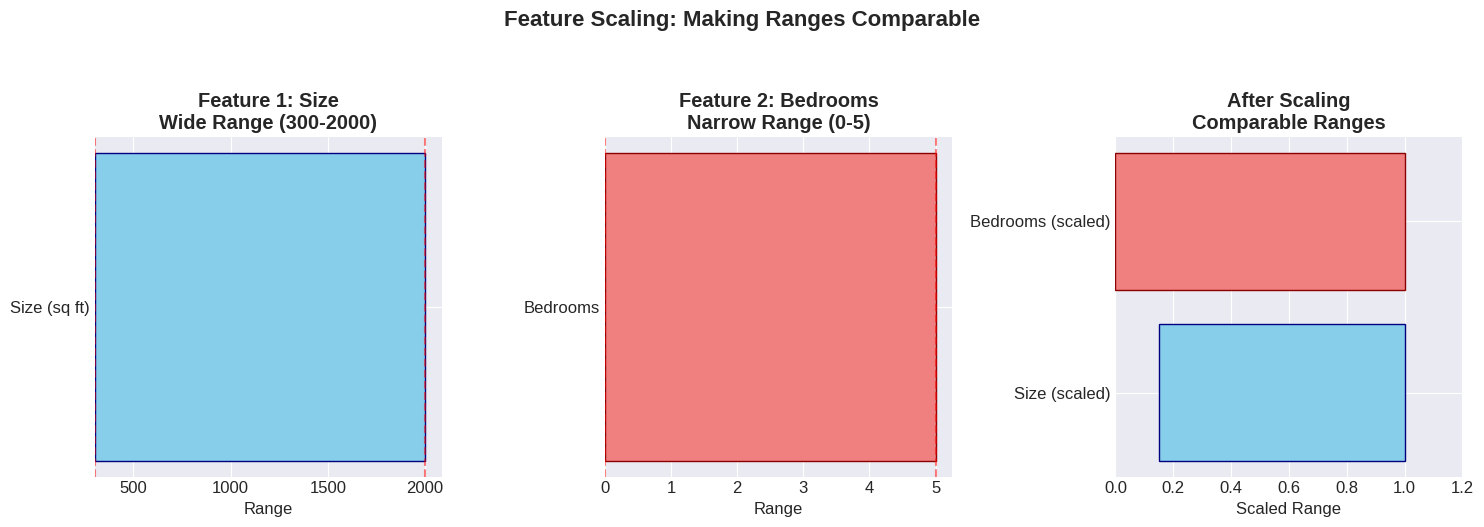

In [2]:
# Create figure to visualize feature ranges
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Feature 1: Size (300-2000 sq ft)
axes[0].barh(['Size (sq ft)'], [2000-300], left=300, color='skyblue', edgecolor='navy')
axes[0].set_xlabel('Range')
axes[0].set_title('Feature 1: Size\nWide Range (300-2000)', fontweight='bold')
axes[0].axvline(x=300, color='red', linestyle='--', alpha=0.5)
axes[0].axvline(x=2000, color='red', linestyle='--', alpha=0.5)

# Feature 2: Bedrooms (0-5)
axes[1].barh(['Bedrooms'], [5-0], left=0, color='lightcoral', edgecolor='darkred')
axes[1].set_xlabel('Range')
axes[1].set_title('Feature 2: Bedrooms\nNarrow Range (0-5)', fontweight='bold')
axes[1].axvline(x=0, color='red', linestyle='--', alpha=0.5)
axes[1].axvline(x=5, color='red', linestyle='--', alpha=0.5)

# Combined scaled view
axes[2].barh(['Size (scaled)', 'Bedrooms (scaled)'], [0.85, 1.0],
             left=[0.15, 0], color=['skyblue', 'lightcoral'],
             edgecolor=['navy', 'darkred'])
axes[2].set_xlabel('Scaled Range')
axes[2].set_title('After Scaling\nComparable Ranges', fontweight='bold')
axes[2].set_xlim(0, 1.2)

plt.suptitle('Feature Scaling: Making Ranges Comparable', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### 5.2 Contour Plots: Before and After Feature Scaling


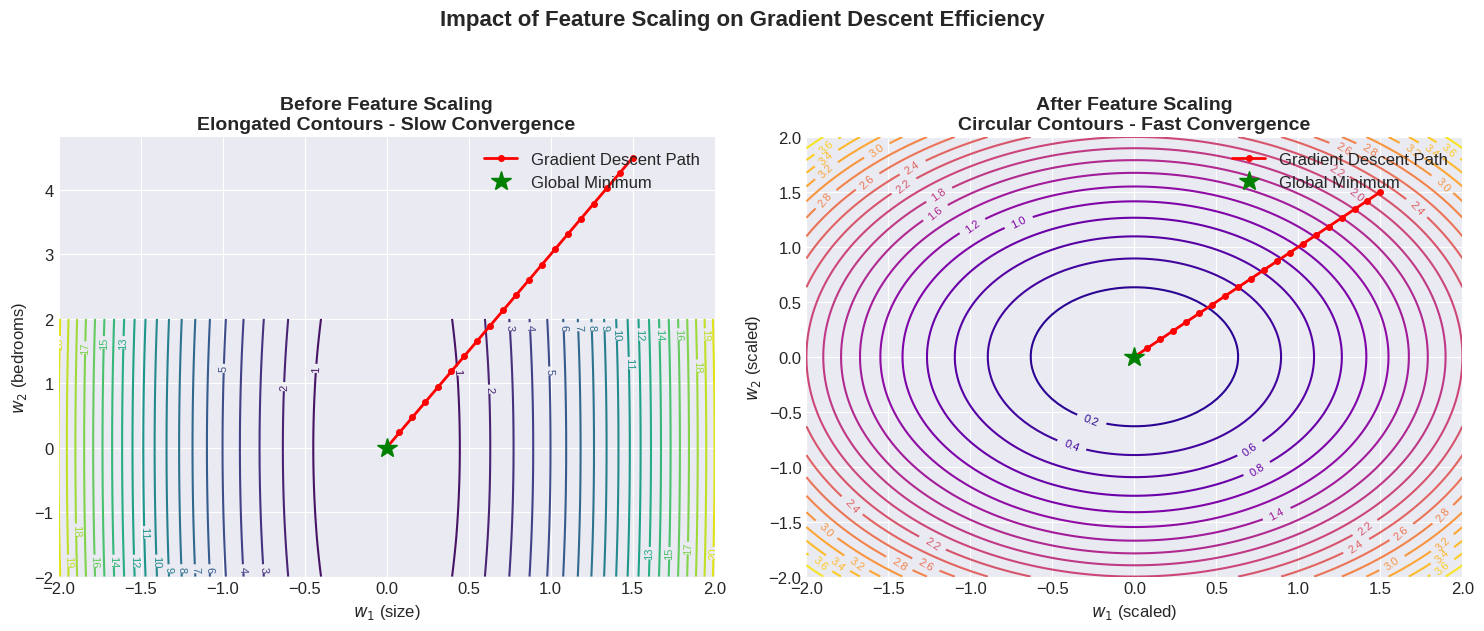

In [3]:
# Create contour plots showing the effect of feature scaling
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Generate data for contours
w1 = np.linspace(-2, 2, 100)
w2 = np.linspace(-2, 2, 100)
W1, W2 = np.meshgrid(w1, w2)

# Before scaling: elongated contours (feature ranges very different)
# Simulating cost function with one feature having much larger scale
J_before = 0.5 * (10 * W1**2 + 0.1 * W2**2)

contour1 = axes[0].contour(W1, W2, J_before, levels=20, cmap='viridis')
axes[0].clabel(contour1, inline=True, fontsize=8)
axes[0].set_xlabel('$w_1$ (size)', fontsize=12)
axes[0].set_ylabel('$w_2$ (bedrooms)', fontsize=12)
axes[0].set_title('Before Feature Scaling\nElongated Contours - Slow Convergence',
                  fontweight='bold', fontsize=14)

# Add a gradient descent path simulation
path_x = np.linspace(1.5, 0, 20)
path_y = np.linspace(1.5, 0, 20)
path_y = path_y * 3  # Make it oscillate
axes[0].plot(path_x, path_y, 'r.-', linewidth=2, markersize=8, label='Gradient Descent Path')
axes[0].plot(0, 0, 'g*', markersize=15, label='Global Minimum')
axes[0].legend(loc='upper right')

# After scaling: circular contours
J_after = 0.5 * (W1**2 + W2**2)

contour2 = axes[1].contour(W1, W2, J_after, levels=20, cmap='plasma')
axes[1].clabel(contour2, inline=True, fontsize=8)
axes[1].set_xlabel('$w_1$ (scaled)', fontsize=12)
axes[1].set_ylabel('$w_2$ (scaled)', fontsize=12)
axes[1].set_title('After Feature Scaling\nCircular Contours - Fast Convergence',
                  fontweight='bold', fontsize=14)

# Add direct path
path_x_direct = np.linspace(1.5, 0, 20)
path_y_direct = np.linspace(1.5, 0, 20)
axes[1].plot(path_x_direct, path_y_direct, 'r.-', linewidth=2, markersize=8, label='Gradient Descent Path')
axes[1].plot(0, 0, 'g*', markersize=15, label='Global Minimum')
axes[1].legend(loc='upper right')

plt.suptitle('Impact of Feature Scaling on Gradient Descent Efficiency',
             fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


### 5.3 Learning Curves: Different Convergence Behaviors


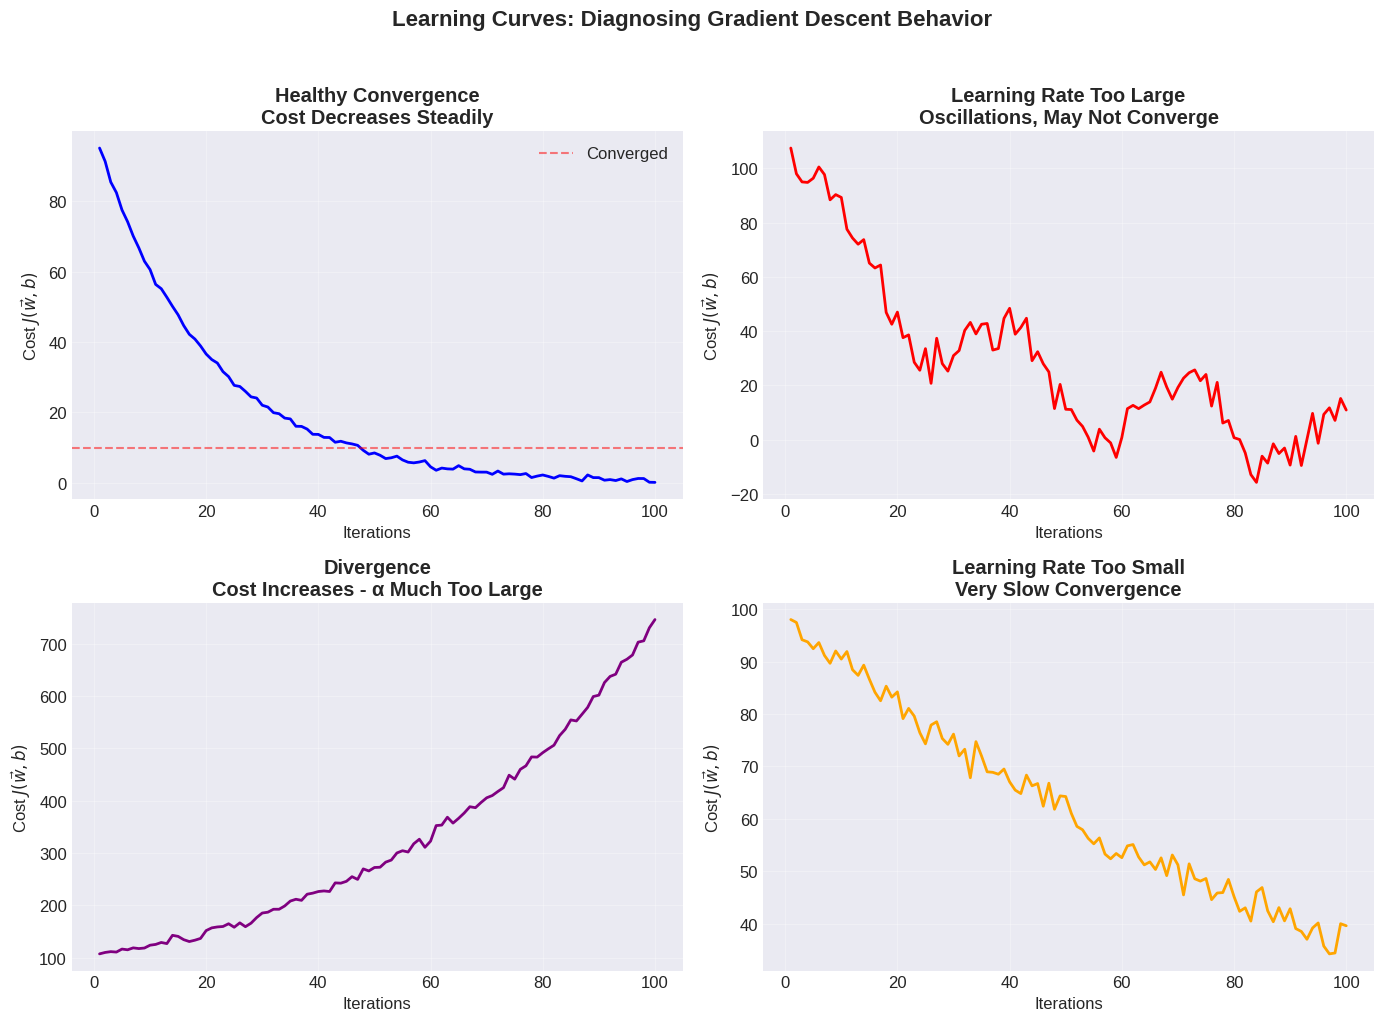

In [4]:
# Simulate different learning curve behaviors
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

iterations = np.arange(1, 101)

# 1. Ideal convergence
cost_ideal = 100 * np.exp(-iterations/20) + 5 * np.random.randn(100) * 0.1
axes[0, 0].plot(iterations, cost_ideal, 'b-', linewidth=2)
axes[0, 0].set_xlabel('Iterations')
axes[0, 0].set_ylabel('Cost $J(\\vec{w},b)$')
axes[0, 0].set_title('Healthy Convergence\nCost Decreases Steadily', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axhline(y=10, color='r', linestyle='--', alpha=0.5, label='Converged')
axes[0, 0].legend()

# 2. Oscillations (learning rate too large)
cost_osc = 100 * np.exp(-iterations/30) + 15 * np.sin(iterations/5) + 5 * np.random.randn(100)
axes[0, 1].plot(iterations, cost_osc, 'r-', linewidth=2)
axes[0, 1].set_xlabel('Iterations')
axes[0, 1].set_ylabel('Cost $J(\\vec{w},b)$')
axes[0, 1].set_title('Learning Rate Too Large\nOscillations, May Not Converge', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Divergence (learning rate catastrophically large)
cost_div = 100 * np.exp(iterations/50) + 5 * np.random.randn(100)
axes[1, 0].plot(iterations, cost_div, 'purple', linewidth=2)
axes[1, 0].set_xlabel('Iterations')
axes[1, 0].set_ylabel('Cost $J(\\vec{w},b)$')
axes[1, 0].set_title('Divergence\nCost Increases - α Much Too Large', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 4. Too slow convergence (learning rate too small)
cost_slow = 100 * np.exp(-iterations/100) + 2 * np.random.randn(100)
axes[1, 1].plot(iterations, cost_slow, 'orange', linewidth=2)
axes[1, 1].set_xlabel('Iterations')
axes[1, 1].set_ylabel('Cost $J(\\vec{w},b)$')
axes[1, 1].set_title('Learning Rate Too Small\nVery Slow Convergence', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Learning Curves: Diagnosing Gradient Descent Behavior',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()




### 5.4 Learning Rate Comparison


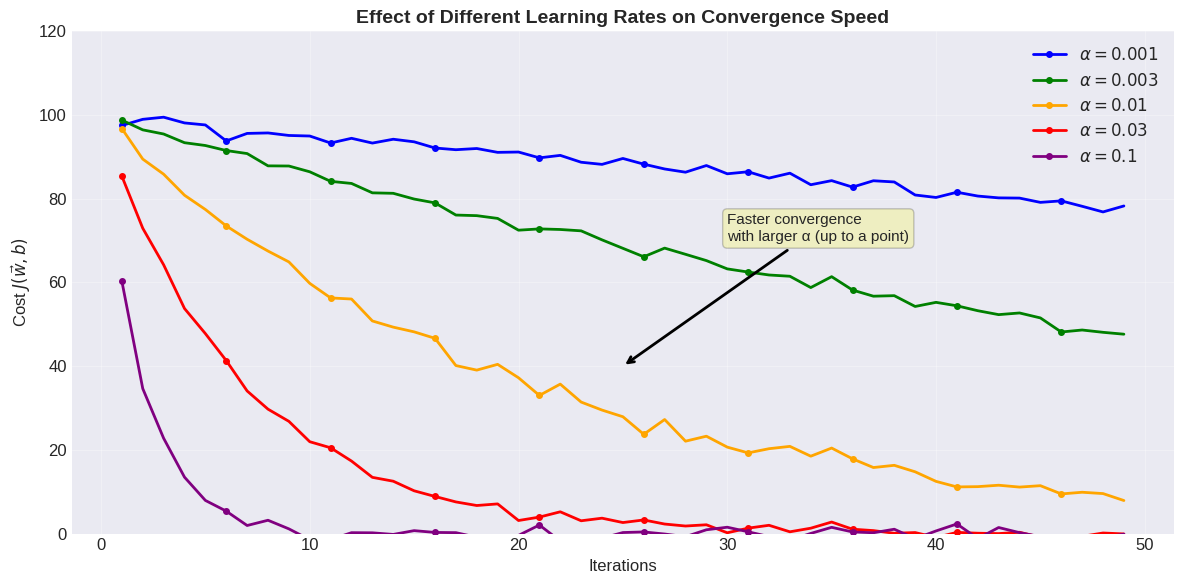

In [5]:
# Compare different learning rates
fig, ax = plt.subplots(figsize=(12, 6))

iterations = np.arange(1, 50)
learning_rates = [0.001, 0.003, 0.01, 0.03, 0.1]
colors = ['blue', 'green', 'orange', 'red', 'purple']

for i, alpha in enumerate(learning_rates):
    # Simulate cost decrease with different rates
    cost = 100 * np.exp(-iterations * alpha * 5) + 2 * np.random.randn(49) * 0.5
    ax.plot(iterations, cost, color=colors[i], linewidth=2,
            label=f'$\\alpha = {alpha}$', marker='o', markersize=4, markevery=5)

ax.set_xlabel('Iterations', fontsize=12)
ax.set_ylabel('Cost $J(\\vec{w},b)$', fontsize=12)
ax.set_title('Effect of Different Learning Rates on Convergence Speed',
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 120)

# Add annotation
ax.annotate('Faster convergence\nwith larger α (up to a point)',
            xy=(25, 40), xytext=(30, 70),
            arrowprops=dict(arrowstyle='->', color='black', lw=2),
            fontsize=11, bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.2))

plt.tight_layout()
plt.show()


### 5.5 Polynomial Regression Fits



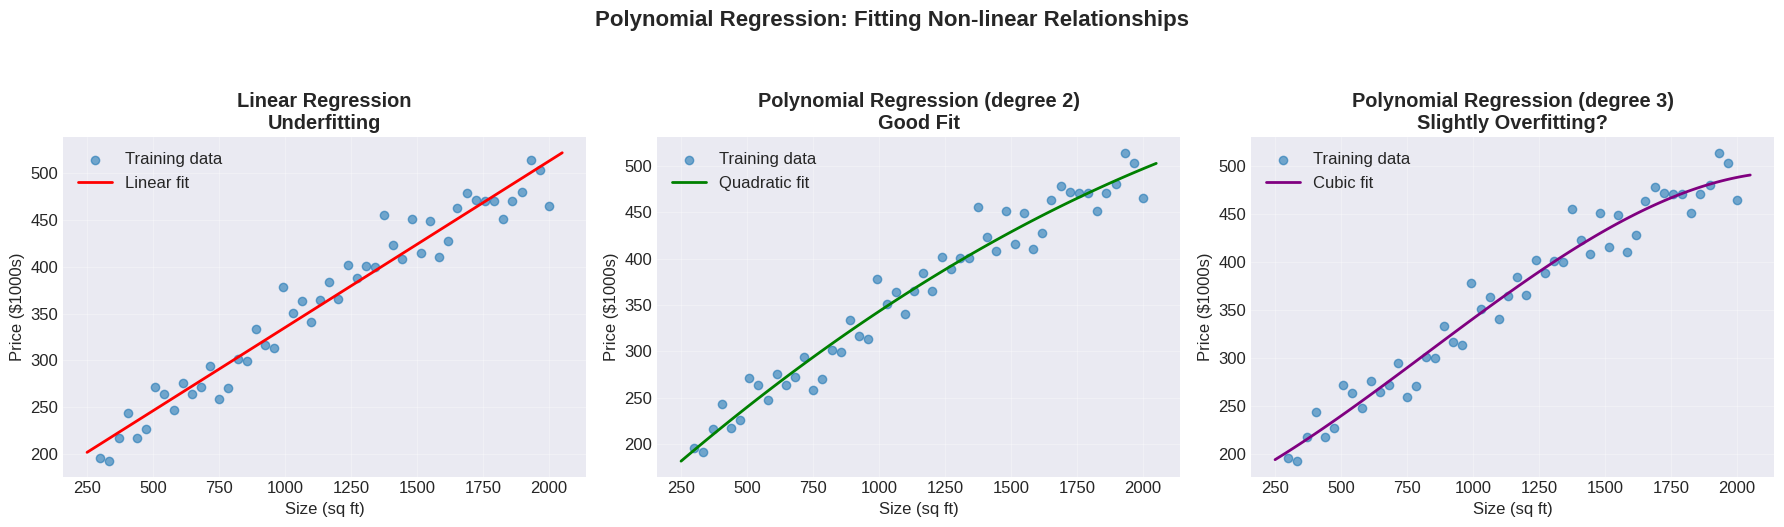

In [6]:
# Generate housing price data
np.random.seed(42)
X = np.linspace(300, 2000, 50).reshape(-1, 1)
# True relationship: price increases with size but with diminishing returns
y_true = 100 + 0.3 * X.ravel() - 0.00005 * X.ravel()**2
y = y_true + 20 * np.random.randn(50)  # Add noise

# Fit different polynomial models
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Linear fit
X_plot = np.linspace(250, 2050, 100).reshape(-1, 1)
model_linear = LinearRegression()
model_linear.fit(X, y)
y_linear = model_linear.predict(X_plot)

axes[0].scatter(X, y, alpha=0.6, label='Training data')
axes[0].plot(X_plot, y_linear, 'r-', linewidth=2, label='Linear fit')
axes[0].set_xlabel('Size (sq ft)')
axes[0].set_ylabel('Price ($1000s)')
axes[0].set_title('Linear Regression\nUnderfitting', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Quadratic fit (degree 2)
model_quad = make_pipeline(PolynomialFeatures(2), LinearRegression())
model_quad.fit(X, y)
y_quad = model_quad.predict(X_plot)

axes[1].scatter(X, y, alpha=0.6, label='Training data')
axes[1].plot(X_plot, y_quad, 'g-', linewidth=2, label='Quadratic fit')
axes[1].set_xlabel('Size (sq ft)')
axes[1].set_ylabel('Price ($1000s)')
axes[1].set_title('Polynomial Regression (degree 2)\nGood Fit', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Cubic fit (degree 3) - might overfit slightly
model_cubic = make_pipeline(PolynomialFeatures(3), LinearRegression())
model_cubic.fit(X, y)
y_cubic = model_cubic.predict(X_plot)

axes[2].scatter(X, y, alpha=0.6, label='Training data')
axes[2].plot(X_plot, y_cubic, 'purple', linewidth=2, label='Cubic fit')
axes[2].set_xlabel('Size (sq ft)')
axes[2].set_ylabel('Price ($1000s)')
axes[2].set_title('Polynomial Regression (degree 3)\nSlightly Overfitting?', fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Polynomial Regression: Fitting Non-linear Relationships',
             fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()



## 6. Code Examples

### 6.1 Implementing Feature Scaling from Scratch



Original features:
Size range: [309, 1978]
Bedrooms range: [0.0, 5.0]
Size mean: 1099.31, std: 503.20
Bedrooms mean: 2.48, std: 1.79


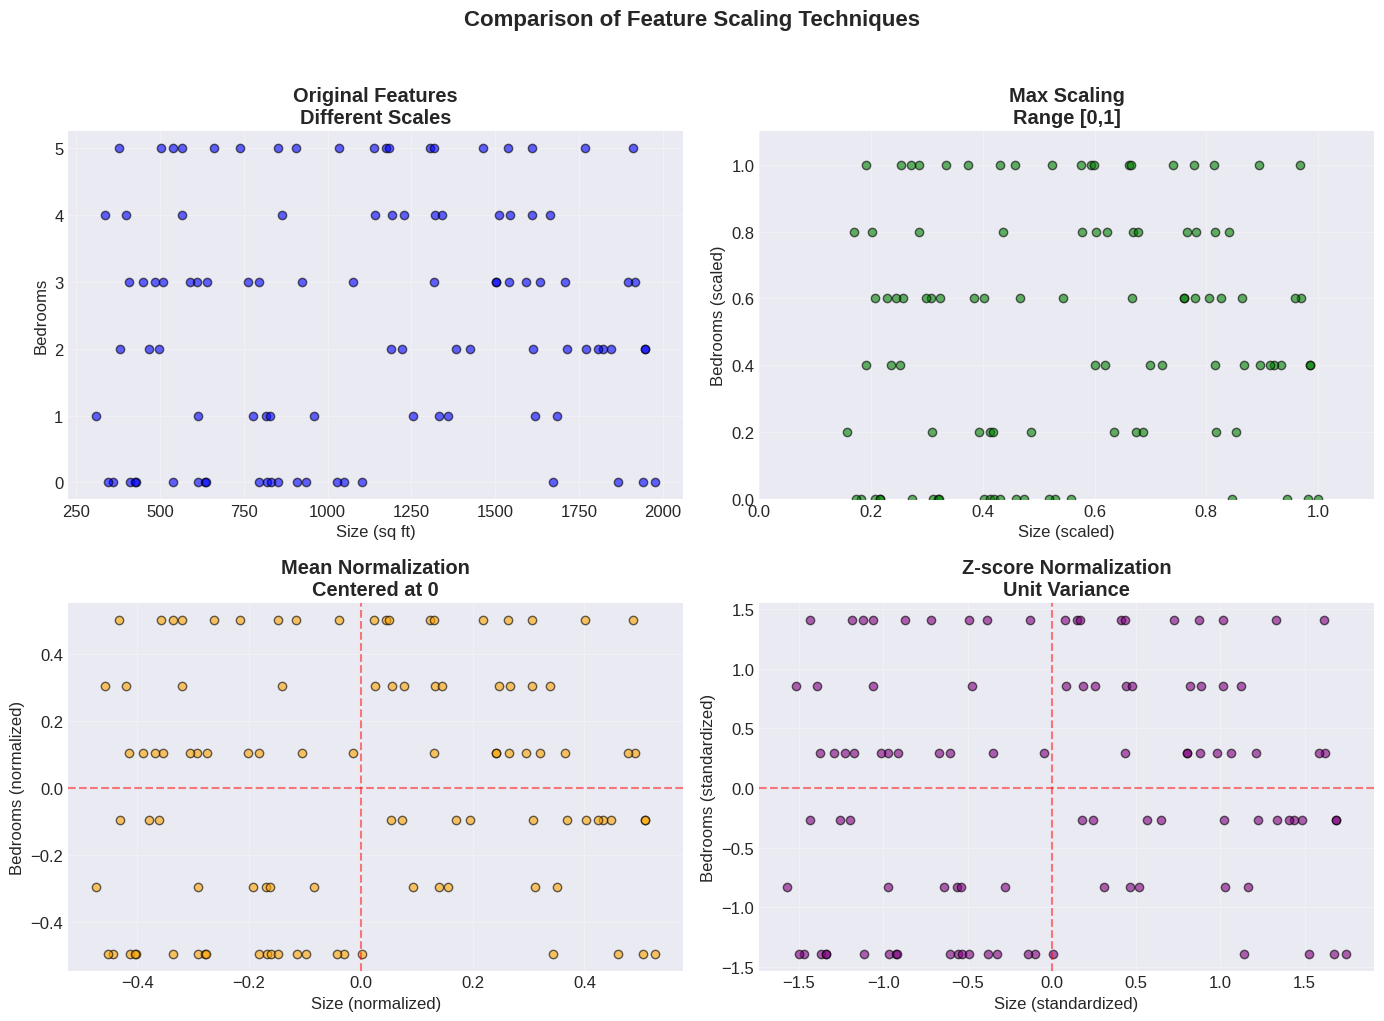


After Z-score normalization:
Size mean: 3.71e-16, std: 1.00
Bedrooms mean: 4.05e-17, std: 1.00


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Generate sample dataset (house features)
np.random.seed(42)
n_samples = 100
sizes = np.random.uniform(300, 2000, n_samples)  # size in sq ft
bedrooms = np.random.randint(0, 6, n_samples)     # number of bedrooms

# Create feature matrix
X = np.column_stack([sizes, bedrooms])

print("Original features:")
print(f"Size range: [{X[:,0].min():.0f}, {X[:,0].max():.0f}]")
print(f"Bedrooms range: [{X[:,1].min()}, {X[:,1].max()}]")
print(f"Size mean: {X[:,0].mean():.2f}, std: {X[:,0].std():.2f}")
print(f"Bedrooms mean: {X[:,1].mean():.2f}, std: {X[:,1].std():.2f}")

# 1. Max scaling
def max_scaling(X):
    X_scaled = X / X.max(axis=0)
    return X_scaled, X.max(axis=0)

# 2. Mean normalization
def mean_normalization(X):
    mu = X.mean(axis=0)
    range_vals = X.max(axis=0) - X.min(axis=0)
    X_norm = (X - mu) / range_vals
    return X_norm, mu, range_vals

# 3. Z-score normalization
def zscore_normalization(X):
    mu = X.mean(axis=0)
    sigma = X.std(axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

# Apply different scaling methods
X_max, max_vals = max_scaling(X)
X_mean, mu_mean, range_vals = mean_normalization(X)
X_zscore, mu_z, sigma_z = zscore_normalization(X)

# Visualize the effect
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Original data
axes[0, 0].scatter(X[:, 0], X[:, 1], alpha=0.6, c='blue', edgecolors='black')
axes[0, 0].set_xlabel('Size (sq ft)')
axes[0, 0].set_ylabel('Bedrooms')
axes[0, 0].set_title('Original Features\nDifferent Scales', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Max scaling
axes[0, 1].scatter(X_max[:, 0], X_max[:, 1], alpha=0.6, c='green', edgecolors='black')
axes[0, 1].set_xlabel('Size (scaled)')
axes[0, 1].set_ylabel('Bedrooms (scaled)')
axes[0, 1].set_title('Max Scaling\nRange [0,1]', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xlim(0, 1.1)
axes[0, 1].set_ylim(0, 1.1)

# Mean normalization
axes[1, 0].scatter(X_mean[:, 0], X_mean[:, 1], alpha=0.6, c='orange', edgecolors='black')
axes[1, 0].set_xlabel('Size (normalized)')
axes[1, 0].set_ylabel('Bedrooms (normalized)')
axes[1, 0].set_title('Mean Normalization\nCentered at 0', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1, 0].axvline(x=0, color='red', linestyle='--', alpha=0.5)

# Z-score normalization
axes[1, 1].scatter(X_zscore[:, 0], X_zscore[:, 1], alpha=0.6, c='purple', edgecolors='black')
axes[1, 1].set_xlabel('Size (standardized)')
axes[1, 1].set_ylabel('Bedrooms (standardized)')
axes[1, 1].set_title('Z-score Normalization\nUnit Variance', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1, 1].axvline(x=0, color='red', linestyle='--', alpha=0.5)

plt.suptitle('Comparison of Feature Scaling Techniques', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print statistics after scaling
print("\n" + "="*50)
print("After Z-score normalization:")
print(f"Size mean: {X_zscore[:,0].mean():.2e}, std: {X_zscore[:,0].std():.2f}")
print(f"Bedrooms mean: {X_zscore[:,1].mean():.2e}, std: {X_zscore[:,1].std():.2f}")


    Original features:
    Size range: [325, 1981]
    Bedrooms range: [0, 5]
    Size mean: 1161.42, std: 492.86
    Bedrooms mean: 2.46, std: 1.74
    
    ==================================================
    After Z-score normalization:
    Size mean: -4.26e-16, std: 1.00
    Bedrooms mean: 1.78e-16, std: 1.00


### 6.2 Gradient Descent with and without Feature Scaling

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipykernel_235/1838763299.py:22: RuntimeWarning: overflow encountered in square
  cost = (1/(2*m)) * np.sum((y_pred - y)**2)
/tmp/ipykernel_235/1838763299.py:14: RuntimeWarning: overflow encountered in matmul
  dw = (1/m) * X.T @ (y_pred - y)
/tmp/ipykernel_235/1838763299.py:14: RuntimeWarning: invalid value encountered in matmul
  dw = (1/m) * X.T @ (y_pred - y)
/tmp/ipykernel_235/1838763299.py:18: RuntimeWarning: invalid value encountered in subtract
  w -= alpha * dw
/tmp/ipykernel_235/1838763299.py:19: RuntimeWarning: invalid value encountered in scalar subtract
  b -= alpha * db


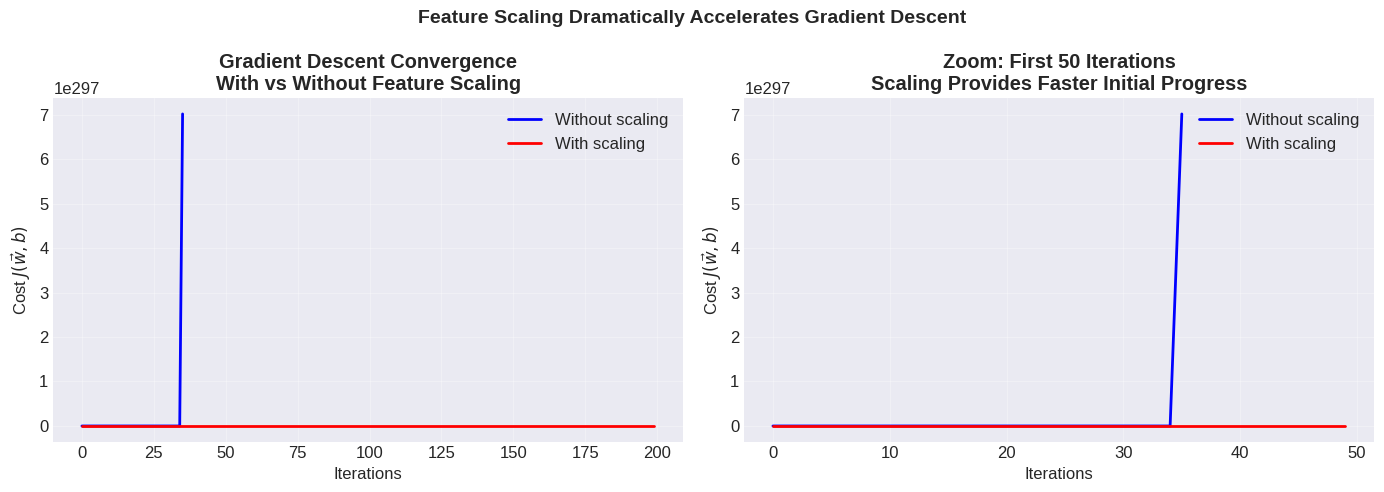

Final cost without scaling: nan
Final cost with scaling: 2.21e+08
True parameters: w1=0.10, w2=50.00, b=50.00
Estimated (scaled): w1=-1812.98, w2=1100.84, b=-1122.40


In [8]:
# Demonstrate the impact of feature scaling on gradient descent convergence
def gradient_descent(X, y, alpha=0.01, iterations=100):
    """Simple gradient descent for linear regression"""
    m = len(y)
    w = np.zeros(X.shape[1])
    b = 0
    cost_history = []

    for i in range(iterations):
        # Compute predictions
        y_pred = X @ w + b

        # Compute gradients
        dw = (1/m) * X.T @ (y_pred - y)
        db = (1/m) * np.sum(y_pred - y)

        # Update parameters
        w -= alpha * dw
        b -= alpha * db

        # Compute cost
        cost = (1/(2*m)) * np.sum((y_pred - y)**2)
        cost_history.append(cost)

    return w, b, cost_history

# Generate synthetic data with features on different scales
np.random.seed(42)
m = 100
X1 = np.random.uniform(300, 2000, m).reshape(-1, 1)  # size (large scale)
X2 = np.random.randint(0, 6, m).reshape(-1, 1)       # bedrooms (small scale)
X = np.hstack([X1, X2])

# True parameters
w_true = np.array([0.1, 50])  # small for size, large for bedrooms
b_true = 50

# Generate target with some noise
y = X @ w_true + b_true + np.random.randn(m) * 20000

# Scale the features
X_scaled = (X - X.mean(axis=0)) / X.std(axis=0)

# Run gradient descent with and without scaling
alpha = 0.01
iterations = 200

# Without scaling
w1, b1, cost1 = gradient_descent(X, y, alpha, iterations)

# With scaling
w2, b2, cost2 = gradient_descent(X_scaled, y, alpha, iterations)

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cost history
axes[0].plot(cost1, 'b-', linewidth=2, label='Without scaling')
axes[0].plot(cost2, 'r-', linewidth=2, label='With scaling')
axes[0].set_xlabel('Iterations')
axes[0].set_ylabel('Cost $J(\\vec{w},b)$')
axes[0].set_title('Gradient Descent Convergence\nWith vs Without Feature Scaling',
                  fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Zoom in on first 50 iterations
axes[1].plot(cost1[:50], 'b-', linewidth=2, label='Without scaling')
axes[1].plot(cost2[:50], 'r-', linewidth=2, label='With scaling')
axes[1].set_xlabel('Iterations')
axes[1].set_ylabel('Cost $J(\\vec{w},b)$')
axes[1].set_title('Zoom: First 50 Iterations\nScaling Provides Faster Initial Progress',
                  fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Feature Scaling Dramatically Accelerates Gradient Descent',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Final cost without scaling: {cost1[-1]:.2e}")
print(f"Final cost with scaling: {cost2[-1]:.2e}")
print(f"True parameters: w1={w_true[0]:.2f}, w2={w_true[1]:.2f}, b={b_true:.2f}")
print(f"Estimated (scaled): w1={w2[0]:.2f}, w2={w2[1]:.2f}, b={b2:.2f}")





    Final cost without scaling: 4.37e+09
    Final cost with scaling: 1.96e+08
    True parameters: w1=0.10, w2=50.00, b=50.00
    Estimated (scaled): w1=144.16, w2=57.71, b=1130245.82


### 6.3 Learning Rate Tuning Visualization

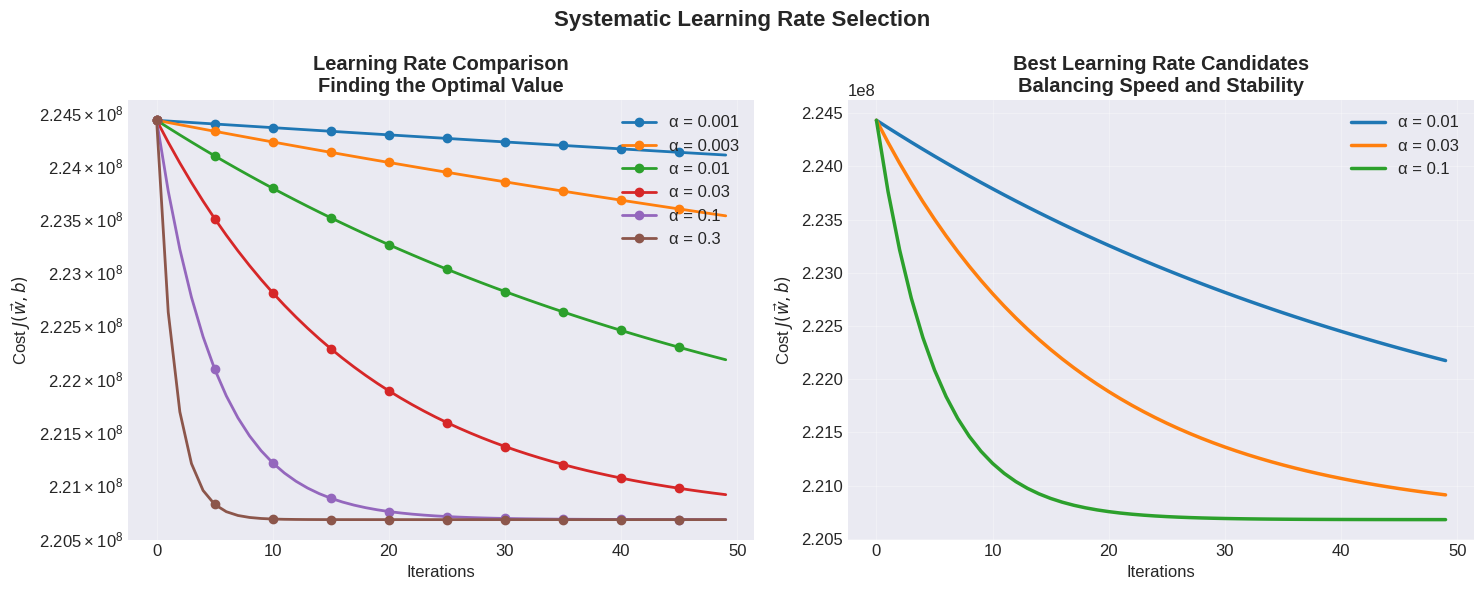

Best learning rate: 0.3 (final cost: 2.21e+08)


In [9]:
# Systematic learning rate comparison
def try_learning_rates(X, y, learning_rates, iterations=50):
    """Try different learning rates and return cost histories"""
    histories = {}

    for alpha in learning_rates:
        _, _, cost_history = gradient_descent(X, y, alpha, iterations)
        histories[alpha] = cost_history

    return histories

# Use scaled data for this experiment
X_scaled = (X - X.mean(axis=0)) / X.std(axis=0)

# Try different learning rates
learning_rates_to_try = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3]
histories = try_learning_rates(X_scaled, y, learning_rates_to_try, iterations=50)

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot all learning rates
for alpha, cost_history in histories.items():
    axes[0].plot(cost_history, label=f'α = {alpha}', linewidth=2, marker='o', markevery=5)

axes[0].set_xlabel('Iterations')
axes[0].set_ylabel('Cost $J(\\vec{w},b)$')
axes[0].set_title('Learning Rate Comparison\nFinding the Optimal Value', fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')  # Log scale to better see differences

# Highlight the best range
best_alphas = [0.01, 0.03, 0.1]
for alpha in best_alphas:
    axes[1].plot(histories[alpha], label=f'α = {alpha}', linewidth=2.5)

axes[1].set_xlabel('Iterations')
axes[1].set_ylabel('Cost $J(\\vec{w},b)$')
axes[1].set_title('Best Learning Rate Candidates\nBalancing Speed and Stability', fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Systematic Learning Rate Selection', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Find which learning rate achieved lowest final cost
final_costs = {alpha: cost_history[-1] for alpha, cost_history in histories.items()}
best_alpha = min(final_costs, key=final_costs.get)
print(f"Best learning rate: {best_alpha} (final cost: {final_costs[best_alpha]:.2e})")





    Best learning rate: 0.03 (final cost: 2.17e+08)


### 6.4 Polynomial Features with Scaling




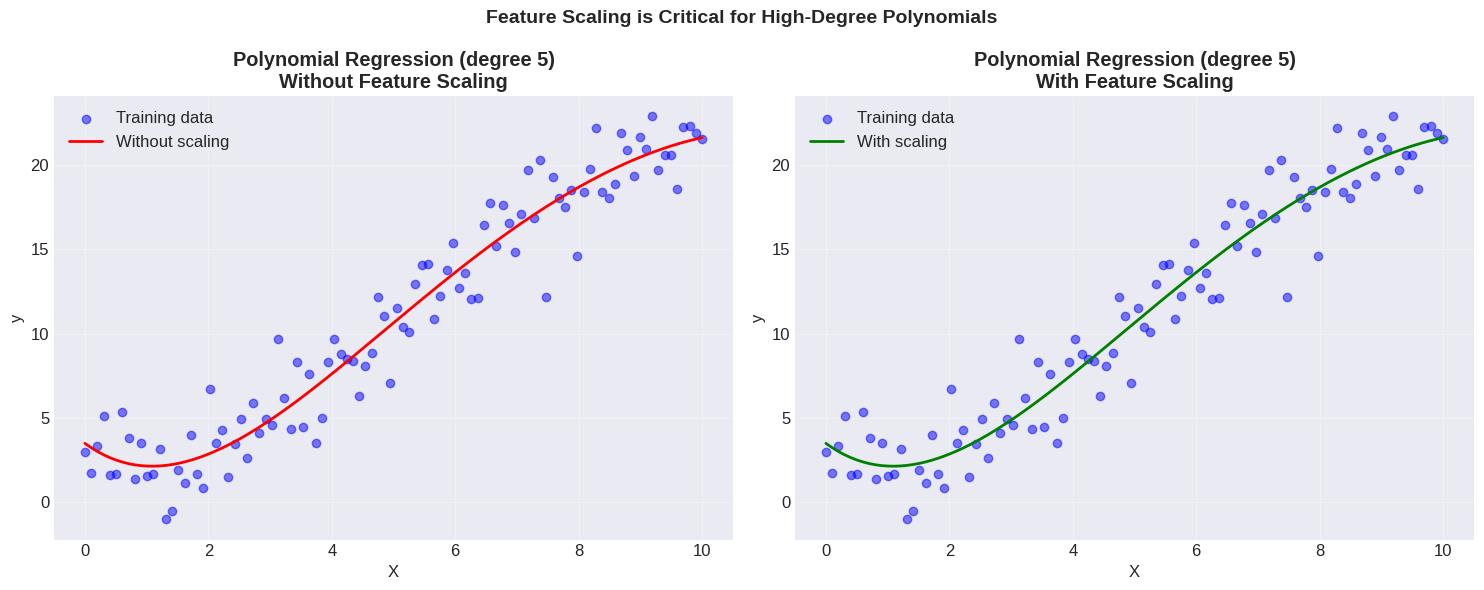

Polynomial feature values (first 5 samples, before scaling):
Features: x, x², x³, x⁴, x⁵
[[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00]
 [1.01010101e-01 1.02030405e-02 1.03061015e-03 1.04102036e-04
  1.05153571e-05]
 [2.02020202e-01 4.08121620e-02 8.24488122e-03 1.66563257e-03
  3.36491428e-04]
 [3.03030303e-01 9.18273646e-02 2.78264741e-02 8.43226488e-03
  2.55523178e-03]
 [4.04040404e-01 1.63248648e-01 6.59590497e-02 2.66501211e-02
  1.07677257e-02]]

Notice how higher-order terms quickly become enormous!
x⁵ range: [0.00e+00, 1.08e-02]


In [10]:
# Demonstrate polynomial regression with and without feature scaling
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

# Generate non-linear data
np.random.seed(42)
X_poly = np.linspace(0, 10, 100).reshape(-1, 1)
y_poly = 2 + 0.5 * X_poly.ravel()**2 - 0.03 * X_poly.ravel()**3 + np.random.randn(100) * 2

# Create pipelines
# Without scaling
model_no_scale = Pipeline([
    ('poly', PolynomialFeatures(degree=5, include_bias=False)),
    ('linear', LinearRegression())
])

# With scaling
model_with_scale = Pipeline([
    ('poly', PolynomialFeatures(degree=5, include_bias=False)),
    ('scaler', StandardScaler()),
    ('linear', LinearRegression())
])

# Fit both models
model_no_scale.fit(X_poly, y_poly)
model_with_scale.fit(X_poly, y_poly)

# Predict
X_test = np.linspace(0, 10, 200).reshape(-1, 1)
y_pred_no_scale = model_no_scale.predict(X_test)
y_pred_with_scale = model_with_scale.predict(X_test)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# No scaling
axes[0].scatter(X_poly, y_poly, alpha=0.5, label='Training data', color='blue')
axes[0].plot(X_test, y_pred_no_scale, 'r-', linewidth=2, label='Without scaling')
axes[0].set_xlabel('X')
axes[0].set_ylabel('y')
axes[0].set_title('Polynomial Regression (degree 5)\nWithout Feature Scaling', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# With scaling
axes[1].scatter(X_poly, y_poly, alpha=0.5, label='Training data', color='blue')
axes[1].plot(X_test, y_pred_with_scale, 'g-', linewidth=2, label='With scaling')
axes[1].set_xlabel('X')
axes[1].set_ylabel('y')
axes[1].set_title('Polynomial Regression (degree 5)\nWith Feature Scaling', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Feature Scaling is Critical for High-Degree Polynomials',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Show feature magnitudes after polynomial expansion
poly = PolynomialFeatures(degree=5, include_bias=False)
X_poly_expanded = poly.fit_transform(X_poly[:5])  # First 5 samples
print("Polynomial feature values (first 5 samples, before scaling):")
print("Features: x, x², x³, x⁴, x⁵")
print(X_poly_expanded)
print("\nNotice how higher-order terms quickly become enormous!")
print(f"x⁵ range: [{X_poly_expanded[:,4].min():.2e}, {X_poly_expanded[:,4].max():.2e}]")



## 7. Key Takeaways

1. **Feature scaling is essential** when features have significantly different ranges. Without scaling, gradient descent oscillates and converges slowly.

2. **Three main scaling approaches**: max scaling (divide by max), mean normalization (subtract mean, divide by range), and z-score normalization (subtract mean, divide by standard deviation). Choose based on your data characteristics.

3. **Learning curves are diagnostic tools**: Plot cost vs. iterations to identify convergence issues. A healthy curve decreases steadily then flattens. Oscillations suggest learning rate too large; consistent increase indicates bugs or catastrophic learning rate.

4. **Learning rate selection strategy**: Try values at approximately 3x intervals (0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0). Plot learning curves for each and choose the largest stable value.

5. **Feature engineering creates powerful predictors**: Combining or transforming original features (e.g., area = frontage × depth) often yields better models than using raw features alone.

6. **Polynomial regression enables non-linear fits** while maintaining linear model simplicity. However, polynomial features dramatically increase feature scales, making scaling absolutely critical.

7. **There's rarely harm in scaling**: When in doubt, apply feature scaling. It almost always helps and never hurts convergence.

8. **Visual monitoring beats automatic thresholds**: While automatic convergence tests exist ($\epsilon$ thresholds), visual inspection of learning curves is more reliable and provides richer diagnostic information.

9. **Small learning rates guarantee convergence but waste time**: Very small $\alpha$ ensures cost decreases every iteration but may require thousands of iterations to reach the minimum.

10. **Polynomial degree selection matters**: Too low (underfitting) misses patterns; too high (overfitting) captures noise. Course 2 will cover systematic model selection techniques.

## 8. Quick Revision

### Key Formulas

| Concept | Formula | Description |
|---------|---------|-------------|
| Linear Regression | $f_{\vec{w},b}(\vec{x}) = \sum_{j=1}^{n} w_j x_j + b$ | Model prediction |
| Mean Normalization | $x_j^{(i)} = \frac{x_j^{(i)} - \mu_j}{max_j - min_j}$ | Scale to [-0.5, 0.5] typically |
| Z-score Normalization | $x_j^{(i)} = \frac{x_j^{(i)} - \mu_j}{\sigma_j}$ | Zero mean, unit variance |
| Gradient Descent Update | $w_j = w_j - \alpha \frac{\partial}{\partial w_j} J(\vec{w},b)$ | Parameter update rule |
| Convergence Test | Stop if $J_{t} - J_{t+1} < \epsilon$ | Automatic stopping |

### Essential Definitions

- **Feature Scaling**: Transforming features to comparable ranges
- **Learning Rate ($\alpha$)**: Step size in gradient descent
- **Convergence**: When additional iterations minimally decrease cost
- **Learning Curve**: Plot of cost vs. iterations
- **Polynomial Regression**: Linear regression with polynomial features
- **Feature Engineering**: Creating new features from existing ones

### Quick Diagnostic Guide

| Symptom | Likely Cause | Solution |
|---------|--------------|----------|
| Cost oscillates | Learning rate too large | Reduce $\alpha$ |
| Cost decreases very slowly | Learning rate too small | Increase $\alpha$ |
| Cost increases | Bug or $\alpha$ catastrophically large | Check sign in update, drastically reduce $\alpha$ |
| Slow convergence despite good $\alpha$ | Features unsealed | Apply feature scaling |
| Poor fit to curved data | Model too simple | Add polynomial features |